# Style Classifier Improvement with Partial Fine-Tuning

## 1. Objective

The objective of this notebook is to improve the fashion style classifier after the real-world evaluation showed weak generalization.

The previous style classifier achieved strong performance on the curated test set, but its performance dropped significantly on the real-world test set. The real-world style accuracy was **0.4750**, and the streetwear class achieved **0.00 recall**.

This notebook tests whether partial fine-tuning can improve the style classifier. Instead of training only the final classification layer, this experiment unfreezes the last ResNet34 block together with the final layer.

The goal is to allow the model to adapt more to fashion-specific visual patterns while still keeping most of the pretrained feature extractor stable.

## 2. Project Context

The recommendation system depends strongly on the predicted style of the input image. The current recommendation logic retrieves items with the same predicted style and a different clothing type.

Because of this, incorrect style predictions directly reduce recommendation quality. For example, if a streetwear item is predicted as gothic, the recommendation system will retrieve gothic items instead of streetwear items.

The real-world evaluation showed that the clothing type classifier remained reasonably reliable, with a real-world accuracy of **0.7500**. The style classifier was the weaker component, with a real-world accuracy of **0.4750**.

The main issue was that streetwear was never predicted correctly in the real-world test set. Many streetwear items were predicted as gothic or sporty. This suggests that the current style model does not learn strong enough boundaries between visually overlapping style categories.

This notebook therefore focuses only on improving the style classifier.

## 3. Approach

The original style baseline used a pretrained ResNet34 model with all pretrained layers frozen. Only the final classification layer was trained.

In this notebook, the model is improved using partial fine-tuning:

1. Load the style training, validation, and test splits from `dataset/split_style`.
2. Load a pretrained ResNet34 model.
3. Replace the final classification layer for the four style classes.
4. Freeze most pretrained layers.
5. Unfreeze `layer4` and the final classification layer.
6. Train the model on the curated style training set.
7. Evaluate the model on the curated validation and test sets.
8. Evaluate the improved model on the real-world test set.
9. Compare the improved model with the previous baseline results.

This experiment keeps the dataset the same and changes only the training strategy. This makes it easier to understand whether fine-tuning improves style generalization.

## 4. Import Libraries

The notebook uses PyTorch and torchvision to train and evaluate the improved style classifier. Pandas is used to organize results, matplotlib is used for visualization, and sklearn is used for evaluation metrics such as classification reports and confusion matrices.

In [1]:
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim

from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

# Reproducibility
random.seed(42)
np.random.seed(42)
torch.manual_seed(42)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(42)

print("torch version:", torch.__version__)
print("cuda available:", torch.cuda.is_available())
print("cuda device count:", torch.cuda.device_count())

if torch.cuda.is_available():
    print("gpu name:", torch.cuda.get_device_name(0))

if torch.cuda.is_available():
    device = torch.device("cuda")
    print("Using device: CUDA")
elif hasattr(torch.backends, "mps") and torch.backends.mps.is_available():
    device = torch.device("mps")
    print("Using device: MPS")
else:
    device = torch.device("cpu")
    print("Using device: CPU")

torch version: 2.11.0+cu130
cuda available: True
cuda device count: 1
gpu name: NVIDIA GeForce RTX 4050 Laptop GPU
Using device: CUDA


## 5. Dataset Paths and Results Folder

This experiment uses the existing style classification split from the `split_style` folder.

The improved model will be evaluated on:

- the curated style test set
- the separate real-world test set

A new results folder is created so the outputs from this improvement experiment are stored separately from the original baseline results.

In [ ]:
train_dir = "../dataset/split_style/train"
val_dir = "../dataset/split_style/val"
test_dir = "../dataset/split_style/test"

real_world_dir = "../dataset/real_world_test"

results_dir = "../results/style_classifier_improvement"
os.makedirs(results_dir, exist_ok=True)

model_output_path = "../models/style_resnet34_finetuned_layer4.pth"

print("Training dataset path:", train_dir)
print("Validation dataset path:", val_dir)
print("Test dataset path:", test_dir)
print("Real-world dataset path:", real_world_dir)
print("Results folder:", results_dir)
print("Model output path:", model_output_path)

Training dataset path: ../dataset/split_style/train
Validation dataset path: ../dataset/split_style/val
Test dataset path: ../dataset/split_style/test
Real-world dataset path: ../dataset/real_world_test
Results folder: ../results/style_classifier_improvement
Model output path: ../models/style_resnet34_finetuned_layer4.pth


## 6. Image Transforms

The same image size and ImageNet normalization are used as in the original style baseline.

For the training set, light augmentation is applied using random horizontal flipping. The validation, test, and real-world evaluation images use only deterministic preprocessing.

In [3]:
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

eval_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

## 7. Load Curated Style Dataset

The curated style dataset is loaded from the existing `split_style` folder.

This dataset contains separate training, validation, and test folders for the four style classes:

- formal
- gothic
- sporty
- streetwear

The same split is used as in the original style baseline so that the improved model can be compared fairly against the previous result.

In [4]:
# Load curated style datasets
train_dataset = datasets.ImageFolder(train_dir, transform=train_transform)
val_dataset = datasets.ImageFolder(val_dir, transform=eval_transform)
test_dataset = datasets.ImageFolder(test_dir, transform=eval_transform)

# Create dataloaders
batch_size = 16

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

# Class names
class_names = train_dataset.classes
num_classes = len(class_names)

print("Classes:", class_names)
print("Number of classes:", num_classes)
print("Training images:", len(train_dataset))
print("Validation images:", len(val_dataset))
print("Test images:", len(test_dataset))

Classes: ['formal', 'gothic', 'sporty', 'streetwear']
Number of classes: 4
Training images: 560
Validation images: 120
Test images: 120


## 8. Dataset Overview

Before training the improved model, the dataset distribution is checked again to confirm that the style split is balanced.

This is important because the new experiment should be compared fairly with the original style baseline.

In [5]:
# Display split sizes
split_summary = pd.DataFrame({
    "Split": ["Train", "Validation", "Test"],
    "Images": [len(train_dataset), len(val_dataset), len(test_dataset)]
})

split_summary

,Split,Images
0,Train,560
1,Validation,120
2,Test,120


### 8.1. Class Distribution

In [6]:
def count_images_per_class(dataset):
    counts = {class_name: 0 for class_name in dataset.classes}

    for _, label in dataset.samples:
        class_name = dataset.classes[label]
        counts[class_name] += 1

    return counts

train_counts = count_images_per_class(train_dataset)
val_counts = count_images_per_class(val_dataset)
test_counts = count_images_per_class(test_dataset)

class_distribution = pd.DataFrame({
    "Train": train_counts,
    "Validation": val_counts,
    "Test": test_counts
})

class_distribution

,Train,Validation,Test
formal,140,30,30
gothic,140,30,30
sporty,140,30,30
streetwear,140,30,30


## 9. Model Selection and Fine-Tuning Strategy

This experiment uses the same `ResNet34` architecture as the original style baseline.

The difference is the training strategy. In the original baseline, all pretrained layers were frozen and only the final classification layer was trained.

In this improved experiment, most pretrained layers remain frozen, but the last ResNet block, `layer4`, is unfrozen together with the final classification layer. This allows the model to adapt more to fashion-specific visual features while still keeping the earlier general image features stable.

In [7]:
# Load pretrained ResNet34
model = models.resnet34(weights=models.ResNet34_Weights.DEFAULT)

# Replace the final classification layer
in_features = model.fc.in_features
model.fc = nn.Linear(in_features, num_classes)

# Freeze all layers first
for param in model.parameters():
    param.requires_grad = False

# Unfreeze the last ResNet block
for param in model.layer4.parameters():
    param.requires_grad = True

# Unfreeze the final classification layer
for param in model.fc.parameters():
    param.requires_grad = True

# Move model to device
model = model.to(device)

print("ResNet34 loaded.")
print("Fine-tuning layer4 and final classification layer.")

ResNet34 loaded.
Fine-tuning layer4 and final classification layer.


In [8]:
# Count trainable and frozen parameters
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
frozen_params = sum(p.numel() for p in model.parameters() if not p.requires_grad)

print("Trainable parameters:", trainable_params)
print("Frozen parameters:", frozen_params)

Trainable parameters: 13116420
Frozen parameters: 8170304


## 10. Training Configuration

For this experiment, the model fine-tunes `layer4` and the final classification layer.

A smaller learning rate is used than in the original baseline because pretrained layers are now being updated. This reduces the risk of damaging useful pretrained features too quickly.

The model is trained using:

- `CrossEntropyLoss` as the loss function
- `Adam` as the optimizer
- `10 epochs` for the first fine-tuning experiment

In [9]:
# Loss function
criterion = nn.CrossEntropyLoss()

# Optimizer only updates unfrozen parameters
optimizer = optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=0.0001
)

# Training settings
num_epochs = 10

print("Training setup ready.")
print("Optimizer: Adam")
print("Learning rate: 0.0001")
print("Number of epochs:", num_epochs)

Training setup ready.
Optimizer: Adam
Learning rate: 0.0001
Number of epochs: 10


## 11. Training and Validation Loop

The model is trained for a fixed number of epochs using the curated style training set.

After each epoch, the model is evaluated on the validation set. Tracking both training and validation metrics helps show whether partial fine-tuning improves learning or causes overfitting.

In [10]:
# Lists to store training history
train_losses = []
val_losses = []
train_accuracies = []
val_accuracies = []

best_val_accuracy = 0.0
best_model_state = None

for epoch in range(num_epochs):
    # ----- Training -----
    model.train()
    running_loss = 0.0
    correct_train = 0
    total_train = 0

    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)

        _, preds = torch.max(outputs, 1)
        correct_train += (preds == labels).sum().item()
        total_train += labels.size(0)

    epoch_train_loss = running_loss / total_train
    epoch_train_acc = correct_train / total_train

    train_losses.append(epoch_train_loss)
    train_accuracies.append(epoch_train_acc)

    # ----- Validation -----
    model.eval()
    running_val_loss = 0.0
    correct_val = 0
    total_val = 0

    with torch.no_grad():
        for images, labels in val_loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            running_val_loss += loss.item() * images.size(0)

            _, preds = torch.max(outputs, 1)
            correct_val += (preds == labels).sum().item()
            total_val += labels.size(0)

    epoch_val_loss = running_val_loss / total_val
    epoch_val_acc = correct_val / total_val

    val_losses.append(epoch_val_loss)
    val_accuracies.append(epoch_val_acc)

    # Save best model state based on validation accuracy
    if epoch_val_acc > best_val_accuracy:
        best_val_accuracy = epoch_val_acc
        best_model_state = model.state_dict()

    print(
        f"Epoch [{epoch+1}/{num_epochs}] | "
        f"Train Loss: {epoch_train_loss:.4f} | Train Acc: {epoch_train_acc:.4f} | "
        f"Val Loss: {epoch_val_loss:.4f} | Val Acc: {epoch_val_acc:.4f}"
    )

print("Best validation accuracy:", round(best_val_accuracy, 4))

Epoch [1/10] | Train Loss: 0.5956 | Train Acc: 0.7714 | Val Loss: 0.2433 | Val Acc: 0.9167
Epoch [2/10] | Train Loss: 0.1487 | Train Acc: 0.9571 | Val Loss: 0.1619 | Val Acc: 0.9333
Epoch [3/10] | Train Loss: 0.0708 | Train Acc: 0.9750 | Val Loss: 0.1284 | Val Acc: 0.9500
Epoch [4/10] | Train Loss: 0.0467 | Train Acc: 0.9929 | Val Loss: 0.0962 | Val Acc: 0.9667
Epoch [5/10] | Train Loss: 0.0262 | Train Acc: 0.9946 | Val Loss: 0.1180 | Val Acc: 0.9333
Epoch [6/10] | Train Loss: 0.0322 | Train Acc: 0.9946 | Val Loss: 0.2335 | Val Acc: 0.9250
Epoch [7/10] | Train Loss: 0.0188 | Train Acc: 0.9964 | Val Loss: 0.1232 | Val Acc: 0.9750
Epoch [8/10] | Train Loss: 0.0277 | Train Acc: 0.9946 | Val Loss: 0.1408 | Val Acc: 0.9500
Epoch [9/10] | Train Loss: 0.0195 | Train Acc: 0.9929 | Val Loss: 0.1301 | Val Acc: 0.9500
Epoch [10/10] | Train Loss: 0.0197 | Train Acc: 0.9964 | Val Loss: 0.0941 | Val Acc: 0.9833
Best validation accuracy: 0.9833


## 12. Load Best Validation Model

During training, the model state with the highest validation accuracy was stored.

Before evaluating on the test sets, the best validation model is loaded back into the model. This ensures that the final evaluation uses the strongest version observed during training.

In [11]:
# Load the best model state before final evaluation
model.load_state_dict(best_model_state)

print("Best validation model loaded.")
print("Best validation accuracy:", round(best_val_accuracy, 4))

Best validation model loaded.
Best validation accuracy: 0.9833


## 13. Training History

The training and validation curves are visualized to understand how the fine-tuned model behaved across epochs.

These plots help identify whether the model improved steadily and whether signs of overfitting appeared during training.

### 13.1. Loss Plot

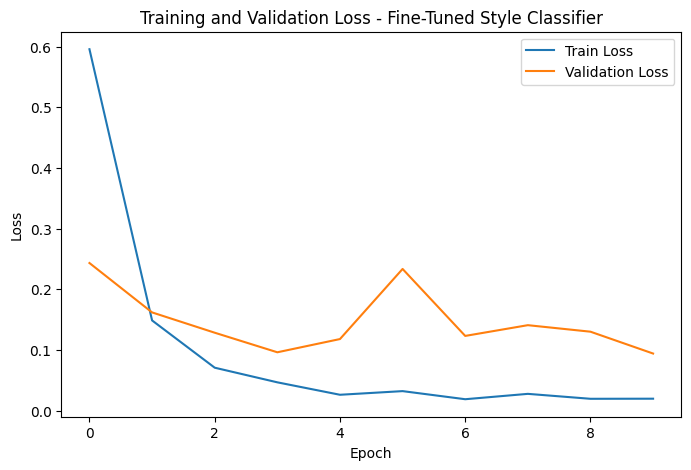

In [12]:
plt.figure(figsize=(8, 5))
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Validation Loss")
plt.title("Training and Validation Loss - Fine-Tuned Style Classifier")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

### 13.2. Accuracy Plot

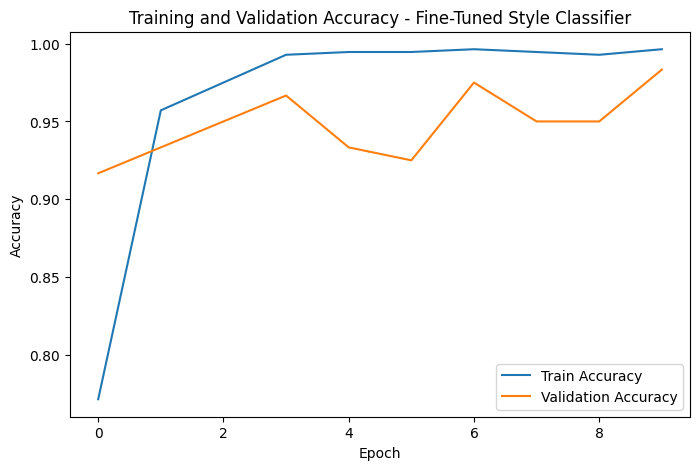

In [13]:
plt.figure(figsize=(8, 5))
plt.plot(train_accuracies, label="Train Accuracy")
plt.plot(val_accuracies, label="Validation Accuracy")
plt.title("Training and Validation Accuracy - Fine-Tuned Style Classifier")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

## 14. Curated Test Set Evaluation

After training and validation, the fine-tuned style classifier is evaluated on the curated test set.

This test set uses the same clean style split as the original style baseline, so the result can be compared directly with the previous baseline accuracy of **0.8417**.

In [14]:
# Evaluate on curated test set
model.eval()

all_test_preds = []
all_test_labels = []

correct_test = 0
total_test = 0

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        _, preds = torch.max(outputs, 1)

        all_test_preds.extend(preds.cpu().numpy())
        all_test_labels.extend(labels.cpu().numpy())

        correct_test += (preds == labels).sum().item()
        total_test += labels.size(0)

curated_test_accuracy = correct_test / total_test

print(f"Curated Test Accuracy: {curated_test_accuracy:.4f}")

Curated Test Accuracy: 0.9417


### 14.1. Curated Test Classification Report

In [15]:
curated_test_report = classification_report(
    all_test_labels,
    all_test_preds,
    target_names=class_names,
    output_dict=True,
    zero_division=0
)

curated_test_report_df = pd.DataFrame(curated_test_report).transpose()
curated_test_report_df

,precision,recall,f1-score,support
formal,1.000000,0.966667,0.983051,30.000000
gothic,1.000000,0.966667,0.983051,30.000000
sporty,0.878788,0.966667,0.920635,30.000000
streetwear,0.896552,0.866667,0.881356,30.000000
accuracy,0.941667,0.941667,0.941667,0.941667
macro avg,0.943835,0.941667,0.942023,120.000000
weighted avg,0.943835,0.941667,0.942023,120.000000


### 14.2. Curated Test Confusion Matrix

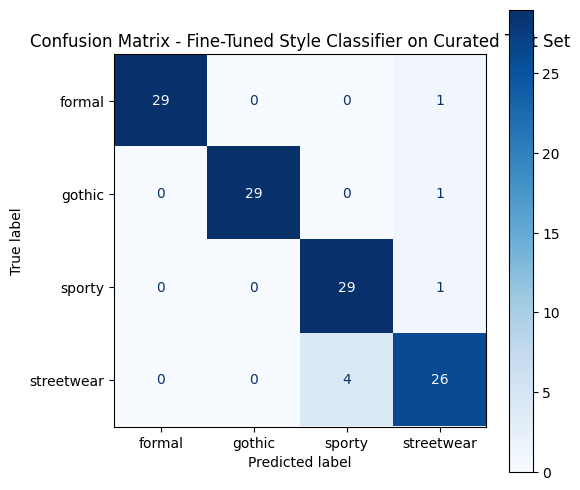

In [16]:
curated_test_cm = confusion_matrix(
    all_test_labels,
    all_test_preds
)

curated_test_disp = ConfusionMatrixDisplay(
    confusion_matrix=curated_test_cm,
    display_labels=class_names
)

fig, ax = plt.subplots(figsize=(6, 6))
curated_test_disp.plot(cmap="Blues", ax=ax)
plt.title("Confusion Matrix - Fine-Tuned Style Classifier on Curated Test Set")
plt.show()

## 15. Real-World Test Set Evaluation

The fine-tuned style classifier is now evaluated on the separate real-world test set.

This is the most important evaluation for this notebook because the previous style model performed weakly on real-world images, achieving only **0.4750** accuracy.

The goal is to check whether partial fine-tuning improves generalization beyond the curated dataset.

In [17]:
valid_extensions = (".jpg", ".jpeg", ".png", ".webp")

real_world_items = []

for style in sorted(os.listdir(real_world_dir)):
    style_path = os.path.join(real_world_dir, style)

    if not os.path.isdir(style_path):
        continue

    for item_type in sorted(os.listdir(style_path)):
        type_path = os.path.join(style_path, item_type)

        if not os.path.isdir(type_path):
            continue

        for filename in sorted(os.listdir(type_path)):
            if not filename.lower().endswith(valid_extensions):
                continue

            image_path = os.path.join(type_path, filename)

            real_world_items.append({
                "image_path": image_path,
                "filename": filename,
                "true_style": style,
                "true_type": item_type
            })

real_world_df = pd.DataFrame(real_world_items)

print("Number of real-world images:", len(real_world_df))
real_world_df.head()

Number of real-world images: 80


,image_path,filename,true_style,true_type
0,../dataset/real_world_test\formal\jacket\forma...,formal_jacket_rw_001.png,formal,jacket
1,../dataset/real_world_test\formal\jacket\forma...,formal_jacket_rw_002.png,formal,jacket
2,../dataset/real_world_test\formal\jacket\forma...,formal_jacket_rw_003.png,formal,jacket
3,../dataset/real_world_test\formal\jacket\forma...,formal_jacket_rw_004.png,formal,jacket
4,../dataset/real_world_test\formal\jacket\forma...,formal_jacket_rw_005.png,formal,jacket


### 15.1. Predict Real-World Styles

In [18]:
def predict_style(image_path):
    image = Image.open(image_path).convert("RGB")
    input_tensor = eval_transform(image).unsqueeze(0).to(device)

    with torch.no_grad():
        outputs = model(input_tensor)
        probs = torch.softmax(outputs, dim=1)

        pred_idx = torch.argmax(probs, dim=1).item()
        predicted_style = class_names[pred_idx]
        confidence = probs[0][pred_idx].item()

    return predicted_style, confidence

In [19]:
real_world_predictions = []

for _, row in real_world_df.iterrows():
    predicted_style, confidence = predict_style(row["image_path"])

    real_world_predictions.append({
        "image_path": row["image_path"],
        "filename": row["filename"],
        "true_style": row["true_style"],
        "true_type": row["true_type"],
        "predicted_style": predicted_style,
        "style_confidence": confidence
    })

real_world_predictions_df = pd.DataFrame(real_world_predictions)

real_world_predictions_df.head()

,image_path,filename,true_style,true_type,predicted_style,style_confidence
0,../dataset/real_world_test\formal\jacket\forma...,formal_jacket_rw_001.png,formal,jacket,formal,0.781402
1,../dataset/real_world_test\formal\jacket\forma...,formal_jacket_rw_002.png,formal,jacket,formal,0.829143
2,../dataset/real_world_test\formal\jacket\forma...,formal_jacket_rw_003.png,formal,jacket,sporty,0.408876
3,../dataset/real_world_test\formal\jacket\forma...,formal_jacket_rw_004.png,formal,jacket,formal,0.939668
4,../dataset/real_world_test\formal\jacket\forma...,formal_jacket_rw_005.png,formal,jacket,formal,0.713069


### 15.2. Real-World Style Accuracy

In [20]:
real_world_style_accuracy = accuracy_score(
    real_world_predictions_df["true_style"],
    real_world_predictions_df["predicted_style"]
)

print(f"Real-World Style Accuracy: {real_world_style_accuracy:.4f}")

Real-World Style Accuracy: 0.4250


### 15.3. Real-World Style Classification Report

In [21]:
real_world_style_report = classification_report(
    real_world_predictions_df["true_style"],
    real_world_predictions_df["predicted_style"],
    labels=class_names,
    target_names=class_names,
    output_dict=True,
    zero_division=0
)

real_world_style_report_df = pd.DataFrame(real_world_style_report).transpose()
real_world_style_report_df

,precision,recall,f1-score,support
formal,0.857143,0.300,0.444444,20.000
gothic,0.319149,0.750,0.447761,20.000
sporty,0.500000,0.600,0.545455,20.000
streetwear,0.500000,0.050,0.090909,20.000
accuracy,0.425000,0.425,0.425000,0.425
macro avg,0.544073,0.425,0.382142,80.000
weighted avg,0.544073,0.425,0.382142,80.000


### 15.4. Real-World Style Confusion Matrix

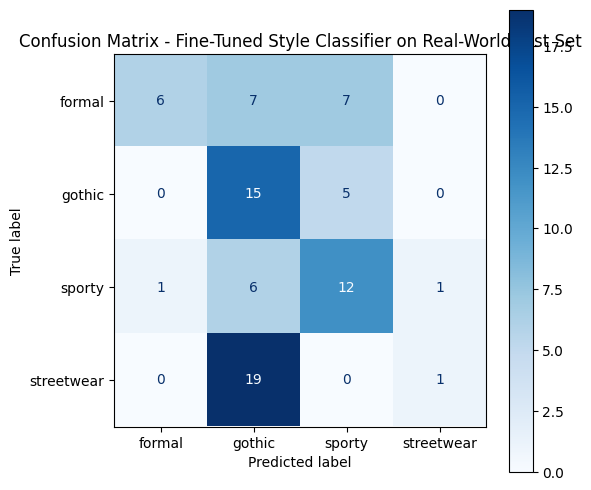

In [22]:
real_world_style_cm = confusion_matrix(
    real_world_predictions_df["true_style"],
    real_world_predictions_df["predicted_style"],
    labels=class_names
)

real_world_style_disp = ConfusionMatrixDisplay(
    confusion_matrix=real_world_style_cm,
    display_labels=class_names
)

fig, ax = plt.subplots(figsize=(6, 6))
real_world_style_disp.plot(cmap="Blues", ax=ax)
plt.title("Confusion Matrix - Fine-Tuned Style Classifier on Real-World Test Set")
plt.show()

## 16. Comparison with Previous Style Baseline

The fine-tuned model is compared with the original style baseline.

The original style baseline trained only the final classification layer. The improved model fine-tuned both `layer4` and the final classification layer.

This comparison shows whether partial fine-tuning improved performance on both the curated test set and the real-world test set.

In [23]:
comparison_df = pd.DataFrame([
    {
        "Model": "Original style baseline",
        "Training strategy": "Frozen feature extractor, trained final layer",
        "Curated test accuracy": 0.8417,
        "Real-world test accuracy": 0.4750
    },
    {
        "Model": "Fine-tuned style model",
        "Training strategy": "Fine-tuned layer4 and final layer",
        "Curated test accuracy": curated_test_accuracy,
        "Real-world test accuracy": real_world_style_accuracy
    }
])

comparison_df

,Model,Training strategy,Curated test accuracy,Real-world test accuracy
0,Original style baseline,"Frozen feature extractor, trained final layer",0.841700,0.475
1,Fine-tuned style model,Fine-tuned layer4 and final layer,0.941667,0.425


## 17. Inspect Incorrect Real-World Predictions

The incorrect real-world predictions are inspected to understand where the fine-tuned model still fails.

This is especially important because the real-world accuracy did not improve, even though the curated test accuracy increased.

In [24]:
incorrect_real_world_df = real_world_predictions_df[
    real_world_predictions_df["true_style"] != real_world_predictions_df["predicted_style"]
].copy()

print("Incorrect real-world style predictions:", len(incorrect_real_world_df))

incorrect_real_world_df[
    ["filename", "true_style", "predicted_style", "style_confidence", "true_type"]
]

Incorrect real-world style predictions: 46


,filename,true_style,predicted_style,style_confidence,true_type
2,formal_jacket_rw_003.png,formal,sporty,0.408876,jacket
5,formal_pants_rw_001.png,formal,sporty,0.478100,pants
6,formal_pants_rw_002.png,formal,gothic,0.825935,pants
7,formal_pants_rw_003.png,formal,sporty,0.447014,pants
8,formal_pants_rw_004.png,formal,gothic,0.828314,pants
9,formal_pants_rw_005.png,formal,sporty,0.931458,pants
10,formal_shoes_rw_001.png,formal,gothic,0.730332,shoes
11,formal_shoes_rw_002.png,formal,sporty,0.681795,shoes
12,formal_shoes_rw_003.png,formal,gothic,0.996413,shoes
13,formal_shoes_rw_004.png,formal,gothic,0.549537,shoes


### 17.1. Visualize Incorrect Real-World Predictions

In [25]:
def show_style_prediction_examples(df, title, max_images=8):
    if len(df) == 0:
        print("No examples to show.")
        return

    sample_df = df.head(max_images)

    cols = min(len(sample_df), 4)
    rows = int(np.ceil(len(sample_df) / cols))

    fig, axes = plt.subplots(rows, cols, figsize=(4 * cols, 4 * rows))

    if rows == 1 and cols == 1:
        axes = np.array([axes])
    else:
        axes = np.array(axes).flatten()

    for i, (_, row) in enumerate(sample_df.iterrows()):
        image = Image.open(row["image_path"]).convert("RGB")
        axes[i].imshow(image)
        axes[i].set_title(
            f"True: {row['true_style']}\n"
            f"Pred: {row['predicted_style']} ({row['style_confidence']:.2f})\n"
            f"Type: {row['true_type']}"
        )
        axes[i].axis("off")

    for j in range(len(sample_df), len(axes)):
        axes[j].axis("off")

    plt.suptitle(title)
    plt.tight_layout()
    plt.show()

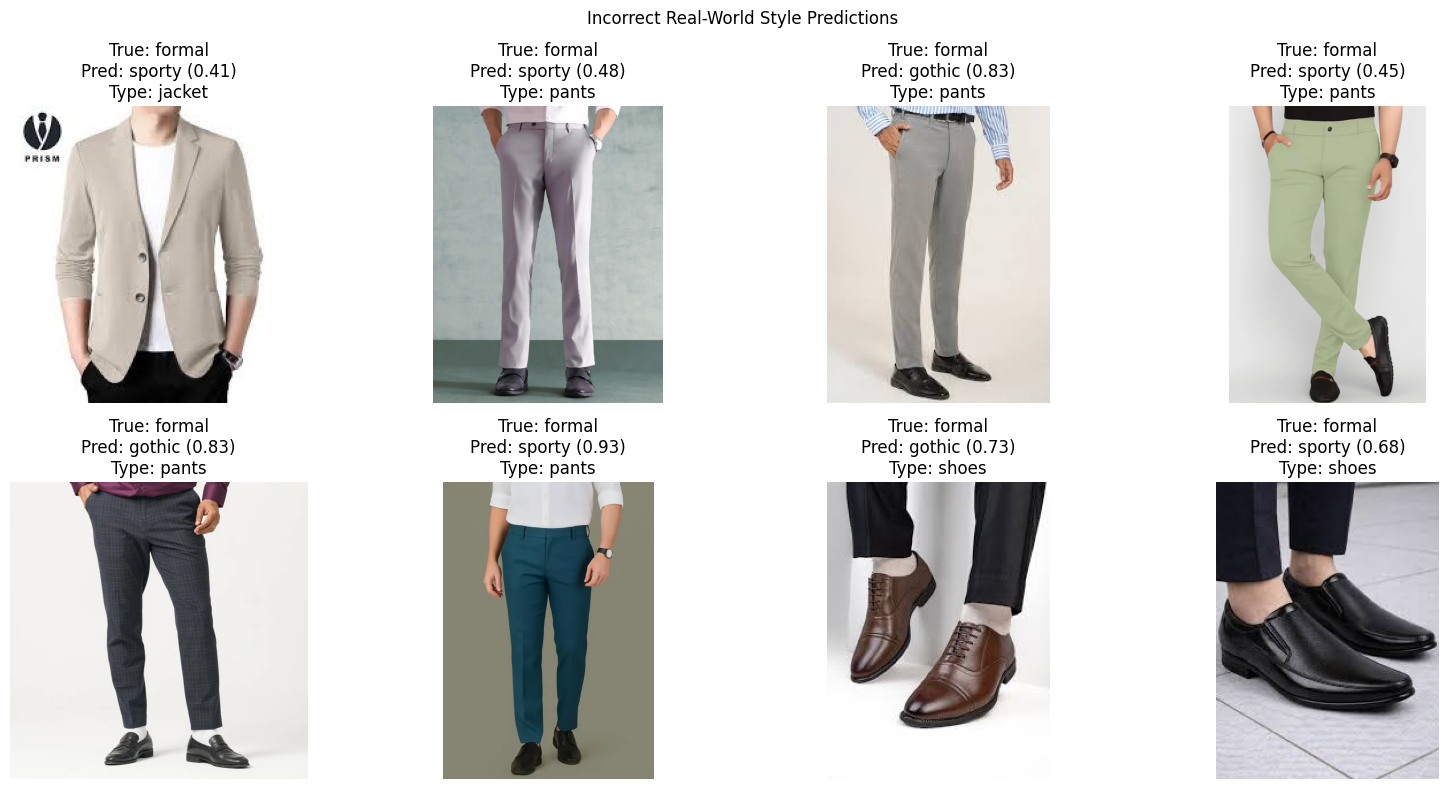

In [26]:
show_style_prediction_examples(
    incorrect_real_world_df,
    "Incorrect Real-World Style Predictions"
)

## 18. Results Interpretation

The fine-tuned style classifier achieved a curated test accuracy of **0.9417**, which is higher than the original style baseline accuracy of **0.8417**. This shows that partial fine-tuning helped the model perform better on the clean curated dataset.

However, the real-world test result did not improve. The fine-tuned model achieved a real-world style accuracy of **0.4250**, which is lower than the original real-world style accuracy of **0.4750**.

This means that the model became better at recognizing the curated dataset, but it did not generalize better to real-world images. The most likely explanation is that the fine-tuned model adapted too strongly to the visual patterns of the curated training set. This improved performance on similar clean images, but made the model less robust when tested on more varied real-world images.

The main issue remains the **streetwear** class. In the real-world confusion matrix, only **1 out of 20** streetwear images was correctly predicted as streetwear. Most streetwear images were predicted as gothic. This suggests that the model does not currently understand streetwear as a separate style category well enough.

The model also struggled with some formal items, especially formal pants and formal shoes. These were often predicted as sporty or gothic. This may be because the real-world formal examples contain colors, poses, and product presentations that differ from the cleaner training dataset.

Overall, this experiment shows that partial fine-tuning alone is not enough to solve the real-world generalization problem. The next improvement should focus more on the dataset, especially by adding more varied real-world streetwear examples and making the style boundaries clearer.

## 19. Limitations

This experiment has several limitations.

First, the model was fine-tuned using the same curated style dataset as the original baseline. Since no new training data was added, the model still learned from a dataset that is cleaner and more controlled than the real-world test set.

Second, only one fine-tuning strategy was tested. This notebook fine-tuned `layer4` and the final classification layer using a learning rate of `0.0001`. Other strategies, such as stronger data augmentation, lower learning rates, early stopping, or fine-tuning fewer layers, may produce different results.

Third, the real-world test set is still relatively small, with **80 images** in total. It is useful for checking generalization, but it is not large enough to act as a final benchmark.

Fourth, style classification remains subjective. Streetwear especially overlaps with sporty and gothic depending on color, silhouette, and styling. This makes the task harder than clothing type classification.

Finally, this notebook only improves and evaluates the style classifier. It does not yet test how the new model affects the full recommendation pipeline.

## 20. Conclusion

This notebook tested whether partial fine-tuning could improve the fashion style classifier.

The fine-tuned ResNet34 model achieved a curated test accuracy of **0.9417**, which is a clear improvement over the original style baseline accuracy of **0.8417**. This shows that unfreezing `layer4` and the final classification layer helped the model learn the curated style dataset better.

However, the real-world style accuracy decreased from **0.4750** to **0.4250**. This shows that the improvement on the curated dataset did not transfer to the real-world dataset.

The main conclusion is that the current issue is not only the model architecture or training strategy. The larger problem is the difference between the curated training dataset and the real-world test images. The model needs more varied and realistic training data, especially for the streetwear class.

The next development step should therefore focus on improving the dataset rather than only changing the model. A useful next step would be to add more real-world-style images to the training data, especially for streetwear, and then retrain or fine-tune the style classifier again.

## 21. Saving the Results

The fine-tuned model, training history, curated test results, real-world test results, and comparison summary are saved to separate files.

This keeps the improvement experiment reproducible and makes it easier to compare it with the original style baseline.

### 21.1. Save Fine-Tuned Model

In [27]:
torch.save({
    "model_state_dict": model.state_dict(),
    "class_names": class_names,
    "training_strategy": "fine_tuned_layer4_and_fc",
    "curated_test_accuracy": curated_test_accuracy,
    "real_world_style_accuracy": real_world_style_accuracy
}, model_output_path)

print("Fine-tuned style model saved.")

Fine-tuned style model saved.


### 21.2. Save Training History

In [28]:
training_history = pd.DataFrame({
    "epoch": range(1, num_epochs + 1),
    "train_loss": train_losses,
    "val_loss": val_losses,
    "train_accuracy": train_accuracies,
    "val_accuracy": val_accuracies
})

training_history.to_csv(
    os.path.join(results_dir, "style_finetuned_training_history.csv"),
    index=False
)

### 21.3. Save Curated Test Results

In [29]:
curated_test_report_df.to_csv(
    os.path.join(results_dir, "style_finetuned_curated_test_classification_report.csv")
)

pd.DataFrame(
    curated_test_cm,
    index=class_names,
    columns=class_names
).to_csv(
    os.path.join(results_dir, "style_finetuned_curated_test_confusion_matrix.csv")
)

### 21.4. Save Real-World Test Results

In [30]:
real_world_predictions_df.to_csv(
    os.path.join(results_dir, "style_finetuned_real_world_predictions.csv"),
    index=False
)

real_world_style_report_df.to_csv(
    os.path.join(results_dir, "style_finetuned_real_world_classification_report.csv")
)

pd.DataFrame(
    real_world_style_cm,
    index=class_names,
    columns=class_names
).to_csv(
    os.path.join(results_dir, "style_finetuned_real_world_confusion_matrix.csv")
)

### 21.5. Save Comparison Summary

In [ ]:
comparison_df.to_csv(
    os.path.join(results_dir, "style_finetuned_comparison_summary.csv"),
    index=False
)

experiment_summary = {
    "experiment": "style_classifier_improvement_finetuned_layer4",
    "model": "ResNet34",
    "training_strategy": "fine-tuned layer4 and final classification layer",
    "epochs": num_epochs,
    "best_validation_accuracy": best_val_accuracy,
    "original_curated_test_accuracy": 0.8417,
    "finetuned_curated_test_accuracy": curated_test_accuracy,
    "original_real_world_style_accuracy": 0.4750,
    "finetuned_real_world_style_accuracy": real_world_style_accuracy,
    "main_result": "curated accuracy improved, but real-world accuracy decreased",
    "next_step": "improve dataset with more varied real-world style images, especially streetwear"
}

pd.DataFrame([experiment_summary]).to_csv(
    os.path.join(results_dir, "style_finetuned_experiment_summary.csv"),
    index=False
)

print("Style classifier improvement results saved successfully.")

Style classifier improvement results saved successfully.
